# Section 1 — Imports

In [1]:
import os
import cv2
import numpy as np
import pandas as pd
from tqdm import tqdm
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.preprocessing import LabelEncoder

# Section 2 — Paths

Change these paths according to your dataset.

In [2]:
# Dataset root
dataset_path = r"C:\Users\Visla\Downloads\s1"

video_files = []

for file in os.listdir(dataset_path):
    if file.endswith(".mpg"):
        video_files.append(file)

print("Total videos:", len(video_files))
print(video_files[:5])

Total videos: 1000
['bbaf2n.mpg', 'bbaf3s.mpg', 'bbaf4p.mpg', 'bbaf5a.mpg', 'bbal6n.mpg']


# Section 3 — Load Metadata

In [3]:
output_folder = "frames"

if not os.path.exists(output_folder):
    os.makedirs(output_folder)

In [4]:
video_path = os.path.join(dataset_path, video_files[0])

cap = cv2.VideoCapture(video_path)

count = 0

while True:
    ret, frame = cap.read()

    if ret == False:
        break

    frame_name = os.path.join(output_folder, f"frame_{count}.jpg")

    cv2.imwrite(frame_name, frame)

    count += 1

cap.release()

print("Frames saved:", count)

Frames saved: 75


In [5]:
video_path = os.path.join(dataset_path, video_files[0])

cap = cv2.VideoCapture(video_path)

frames = []

while True:
    ret, frame = cap.read()

    if ret == False:
        break

    frame = cv2.resize(frame, (224, 224))

    frames.append(frame)

cap.release()

print("Total Frames:", len(frames))
print("Frame Shape:", frames[0].shape)

Total Frames: 75
Frame Shape: (224, 224, 3)


In [6]:
import cv2

def extract_frames(video_path):

    frames = []

    cap = cv2.VideoCapture(video_path)

    while True:

        ret, frame = cap.read()

        if ret == False:
            break

        frame = cv2.resize(frame, (224, 224))

        frames.append(frame)

    cap.release()

    return frames

In [7]:
all_videos = []

for file in video_files:

    video_path = os.path.join(dataset_path, file)

    frames = extract_frames(video_path)

    all_videos.append(frames)

print("Videos Processed:", len(all_videos))

Videos Processed: 1000


In [221]:
DATASET_PATH = r"C:\Users\Visla\Downloads\manit_internship_project\Astronaut_Visual_Speech_Recognition\notebook\mouth_dataset"

folders = os.listdir(DATASET_PATH)

In [220]:
import pandas as pd

meta = pd.read_csv(
    r"C:\Users\Visla\Downloads\manit_internship_project\Astronaut_Visual_Speech_Recognition\results\phase1\video_metadata.csv"
)

mouth_meta = pd.DataFrame()

mouth_meta["Video_ID"] = meta["Filename"].str.replace(".mpg", "", regex=False)

mouth_meta["Transcript"] = meta["Transcript"]

mouth_meta.to_csv("mouth_metadata.csv", index=False)

print("mouth_metadata.csv created successfully")
print(mouth_meta.head())

mouth_metadata.csv created successfully
  Video_ID                 Transcript
0   bbaf2n      bin blue at f two now
1   bbaf3s   bin blue at f three soon
2   bbaf4p  bin blue at f four please
3   bbaf5a   bin blue at f five again
4   bbal6n      bin blue at l six now


In [3]:
import string

def clean_text(text):

    text = text.lower()

    text = text.translate(
        str.maketrans("", "", string.punctuation)
    )

    return text

meta["Transcript"] = meta["Transcript"].apply(clean_text)

In [4]:
texts = meta["Transcript"]

all_text = " ".join(texts)

vocab = sorted(set(all_text))

print(vocab)
print("Vocabulary Size:", len(vocab))

[' ', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z']
Vocabulary Size: 27


In [5]:
char_to_num = {}

for i, char in enumerate(vocab):
    char_to_num[char] = i + 1

num_to_char = {}

for char, num in char_to_num.items():
    num_to_char[num] = char

print(char_to_num)

{' ': 1, 'a': 2, 'b': 3, 'c': 4, 'd': 5, 'e': 6, 'f': 7, 'g': 8, 'h': 9, 'i': 10, 'j': 11, 'k': 12, 'l': 13, 'm': 14, 'n': 15, 'o': 16, 'p': 17, 'q': 18, 'r': 19, 's': 20, 't': 21, 'u': 22, 'v': 23, 'w': 24, 'x': 25, 'y': 26, 'z': 27}


In [23]:
meta = pd.read_csv(
    r"C:\Users\Visla\Downloads\manit_internship_project\Astronaut_Visual_Speech_Recognition\results\phase1\video_metadata.csv"
)

print(meta.shape)
meta.head()

(1000, 13)


,Filename,Extension,Path,File Size,Width,Height,Resolution,FPS,Duration,Frame Count,Readable,Corrupted,Transcript
0,bbaf2n.mpg,.mpg,C:\Users\prash\Downloads\archive (3)\data\s1\b...,452608,360,288,360 x 288,25.0,3.0,75,True,False,bin blue at f two now
1,bbaf3s.mpg,.mpg,C:\Users\prash\Downloads\archive (3)\data\s1\b...,438272,360,288,360 x 288,25.0,3.0,75,True,False,bin blue at f three soon
2,bbaf4p.mpg,.mpg,C:\Users\prash\Downloads\archive (3)\data\s1\b...,430080,360,288,360 x 288,25.0,3.0,75,True,False,bin blue at f four please
3,bbaf5a.mpg,.mpg,C:\Users\prash\Downloads\archive (3)\data\s1\b...,446464,360,288,360 x 288,25.0,3.0,75,True,False,bin blue at f five again
4,bbal6n.mpg,.mpg,C:\Users\prash\Downloads\archive (3)\data\s1\b...,428032,360,288,360 x 288,25.0,3.0,75,True,False,bin blue at l six now


# Create Video_ID Column

In [24]:
meta["Video_ID"] = meta["Filename"].str.replace(
    ".mpg",
    "",
    regex=False
)

print(meta[["Filename", "Video_ID"]].head())

     Filename Video_ID
0  bbaf2n.mpg   bbaf2n
1  bbaf3s.mpg   bbaf3s
2  bbaf4p.mpg   bbaf4p
3  bbaf5a.mpg   bbaf5a
4  bbal6n.mpg   bbal6n


In [25]:
import string

def clean_text(text):

    text = text.lower()

    text = text.translate(
        str.maketrans("", "", string.punctuation)
    )

    return text

In [26]:
meta["Transcript"] = (
    meta["Transcript"]
    .astype(str)
    .apply(clean_text)
)

meta.head()

,Filename,Extension,Path,File Size,Width,Height,Resolution,FPS,Duration,Frame Count,Readable,Corrupted,Transcript,Video_ID
0,bbaf2n.mpg,.mpg,C:\Users\prash\Downloads\archive (3)\data\s1\b...,452608,360,288,360 x 288,25.0,3.0,75,True,False,bin blue at f two now,bbaf2n
1,bbaf3s.mpg,.mpg,C:\Users\prash\Downloads\archive (3)\data\s1\b...,438272,360,288,360 x 288,25.0,3.0,75,True,False,bin blue at f three soon,bbaf3s
2,bbaf4p.mpg,.mpg,C:\Users\prash\Downloads\archive (3)\data\s1\b...,430080,360,288,360 x 288,25.0,3.0,75,True,False,bin blue at f four please,bbaf4p
3,bbaf5a.mpg,.mpg,C:\Users\prash\Downloads\archive (3)\data\s1\b...,446464,360,288,360 x 288,25.0,3.0,75,True,False,bin blue at f five again,bbaf5a
4,bbal6n.mpg,.mpg,C:\Users\prash\Downloads\archive (3)\data\s1\b...,428032,360,288,360 x 288,25.0,3.0,75,True,False,bin blue at l six now,bbal6n


In [27]:
all_text = "".join(meta["Transcript"])

vocab = sorted(set(all_text))

print(vocab)
print("Vocabulary Size:", len(vocab))

[' ', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z']
Vocabulary Size: 27


In [28]:
char_to_num = {
    c:i+1
    for i,c in enumerate(vocab)
}

num_to_char = {
    i+1:c
    for i,c in enumerate(vocab)
}

print(char_to_num)

{' ': 1, 'a': 2, 'b': 3, 'c': 4, 'd': 5, 'e': 6, 'f': 7, 'g': 8, 'h': 9, 'i': 10, 'j': 11, 'k': 12, 'l': 13, 'm': 14, 'n': 15, 'o': 16, 'p': 17, 'q': 18, 'r': 19, 's': 20, 't': 21, 'u': 22, 'v': 23, 'w': 24, 'x': 25, 'y': 26, 'z': 27}


In [29]:
DATASET_PATH = r"C:\Users\Visla\Downloads\manit_internship_project\Astronaut_Visual_Speech_Recognition\notebook\mouth_dataset"

# Evaluate Multiple Videos

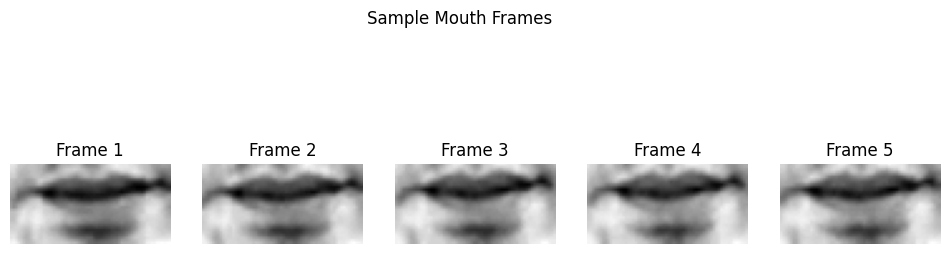

In [206]:
import matplotlib.pyplot as plt

video_id = "bbaf2n"

sample = load_sequence(video_id)

plt.figure(figsize=(12,4))

for i in range(5):

    plt.subplot(1,5,i+1)

    plt.imshow(
        sample[i].squeeze(),
        cmap="gray"
    )

    plt.axis("off")
    plt.title(f"Frame {i+1}")

plt.suptitle("Sample Mouth Frames")
plt.show()